<a href="https://colab.research.google.com/github/atik-bd/MSc-Thesis-Sentiment-Analysis-BERT/blob/main/Atik_Mahbub_20062447_MSc_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

Dissertation submitted in partial fulfilment of the requirements for the degree of Master of Science in Business Analytics at Dublin Business School

> **COMPARATIVE ANALYSIS OF TRANSFORMER-BASED AND TRADITIONAL MODELS FOR PREDICTING CUSTOMER REVIEW SCORES IN HILTON HOTEL REVIEWS**

> Atik Mahbub, ID: 20062447, Dublin Business School

> Supervisor: Claudio Gonzalez Penaloza

> January 2026




# Data Collection and Pre-processing

## Importing Libraries

In [ ]:
# Installing necessary libraries
!pip install --upgrade scikit-learn yellowbrick
!pip install -q transformers datasets accelerate scikeras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import ast
from wordcloud import WordCloud, STOPWORDS
import joblib
import os

import nltk
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize, RegexpTokenizer
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import random
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

!pip -q install emoji contractions

## Create Helper Utilities

In [ ]:
%%writefile utils.py
import re
from typing import Iterable, List, Tuple, Dict
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, mean_absolute_error

DOMAIN_STOPWORDS = {
    "hotel", "hotels", "hilton", "hiltons", "london", "terminal", "south", "park",
    "paddington", "station", "flight", "flights"
}

def normalize_text(text: str) -> str:
    """
    Comprehensive text normalisation for sentiment / review analysis.
    Handles:
      - lowercasing
      - URLs / HTML
      - contractions (if contractions is installed)
      - emojis (if emoji is installed)
      - repeated spaces and punctuation noise
      - removal of domain-specific stopwords
    """
    if text is None:
        return ""
    text = str(text)

    # Strip HTML
    text = re.sub(r"<[^>]+>", " ", text)

    # URLs / emails
    text = re.sub(r"(https?://\S+|www\.\S+)", " URL ", text)
    text = re.sub(r"\S+@\S+\.\S+", " EMAIL ", text)

    # Basic normalize
    text = text.replace("\n", " ").replace("\t", " ")

    # Expand contractions
    try:
        import contractions
        text = contractions.fix(text)
    except Exception:
        # Minimal fallback
        text = re.sub(r"\bcan't\b", "can not", text, flags=re.IGNORECASE)
        text = re.sub(r"\bwon't\b", "will not", text, flags=re.IGNORECASE)
        text = re.sub(r"n't\b", " not", text, flags=re.IGNORECASE)

    # Emoji \u2192 text tokens
    try:
        import emoji
        text = emoji.demojize(text, delimiters=(" ", " "))
        text = re.sub(r":([a-zA-Z_]+):", r" \1 ", text)  # remove colons
    except Exception:
        pass

    text = text.lower()
    # Remove remaining non-word noise
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # Remove domain-specific stopwords
    text = " ".join([w for w in text.split() if w not in DOMAIN_STOPWORDS])

    return text

def compute_metrics(y_true, y_pred, model_name: str = "Model") -> Dict[str, float]:
    """
    Classification metrics + MAE (ordinal-aware).
    MAE penalises far-off rating errors more heavily than near-misses.
    """
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    mae = mean_absolute_error(y_true, y_pred)

    print(f"\n===== {model_name} Metrics =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"MAE      : {mae:.4f}")
    return {"model": model_name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "mae": mae}

def load_glove_embeddings(glove_path: str, embedding_dim: int) -> Dict[str, np.ndarray]:
    """
    Load GloVe vectors from a local .txt file.
    Expected format: word val1 val2 ... valN
    """
    embeddings: Dict[str, np.ndarray] = {}
    with open(glove_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.rstrip().split(" ")
            if len(parts) != embedding_dim + 1:
                continue
            word = parts[0]
            vec = np.asarray(parts[1:], dtype="float32")
            embeddings[word] = vec
    return embeddings

def build_embedding_matrix(word_index: Dict[str, int], embeddings: Dict[str, np.ndarray], embedding_dim: int) -> np.ndarray:
    """
    Build an embedding matrix aligned to a Keras Tokenizer word_index.
    """
    vocab_size = len(word_index) + 1
    matrix = np.random.normal(0, 0.05, size=(vocab_size, embedding_dim)).astype("float32")
    matrix[0] = 0.0  # padding token
    hits = 0
    for word, idx in word_index.items():
        vec = embeddings.get(word)
        if vec is not None:
            matrix[idx] = vec
            hits += 1
    print(f"Loaded pretrained vectors for {hits:,} / {len(word_index):,} tokens ({hits/ max(1,len(word_index)):.1%}).")
    return matrix

def top_ngrams(texts: Iterable[str], ngram_range=(1,3), top_k: int = 25) -> List[Tuple[str, int]]:
    """
    Extract top n-grams by raw frequency using CountVectorizer.
    """
    from sklearn.feature_extraction.text import CountVectorizer
    vec = CountVectorizer(ngram_range=ngram_range, min_df=2)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = freqs.argsort()[::-1][:top_k]
    return list(zip(vocab[top_idx].tolist(), freqs[top_idx].astype(int).tolist()))


import torch
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(y: np.ndarray, num_classes: int) -> torch.Tensor:
    """Return torch float tensor of class weights for CrossEntropyLoss."""
    classes = np.arange(num_classes)
    w = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    return torch.tensor(w, dtype=torch.float)

def train_one_epoch_weighted(model, loader, optimizer, scheduler, device, class_weights: torch.Tensor):
    model.train()
    total_loss = 0.0
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = loss_fn(logits, labels)

        total_loss += float(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
    return total_loss / max(1, len(loader))

@torch.no_grad()
def eval_model_weighted(model, loader, device, class_weights: torch.Tensor):
    model.eval()
    total_loss = 0.0
    all_labels, all_preds = [], []
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        loss = loss_fn(logits, labels)
        total_loss += float(loss.item())

        preds = torch.argmax(logits, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / max(1, len(loader))
    # reuse compute_metrics for acc/prec/rec/f1/mae
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average="weighted", zero_division=0)
    mae = mean_absolute_error(all_labels, all_preds)
    return avg_loss, acc, prec, rec, f1, mae, np.array(all_labels), np.array(all_preds)

Overwriting utils.py


In [ ]:
# Import compute_metrics from utils.py
from utils import compute_metrics

## Load & Read Data

In [ ]:
# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA L4


## Data Understanding

In [ ]:
# Connecting to Google drive

from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading the dataset

file_path = "/content/drive/MyDrive/DataSets/tripadvisor_scraped_hotel_reviews.csv"
raw_data = pd.read_csv(file_path)

In [ ]:
# Checking the features and no. of records in the dataset

print("The number of records are : ", raw_data.shape[0])
print("The number of features are : ", raw_data.shape[1])
print("The list of features is : ", raw_data.columns)
raw_data.head()

The number of records are :  35078
The number of features are :  5
The list of features is :  Index(['hotel_name', 'review_summary', 'review_p1', 'review_p2', 'score'], dtype='object')


,hotel_name,review_summary,review_p1,review_p2,score
0,Hotel Hilton London Gatwick Airport,Awful...,Its hard to find words that can describe this ...,"its just all a bit 'run down' Poor food, not...","<span class=""ui_bubble_rating bubble_10""></span>"
1,Hotel Hilton London Gatwick Airport,Great start to hokidat,Staying in a hotel that’s part of the airport ...,NaN,"<span class=""ui_bubble_rating bubble_50""></span>"
2,Hotel Hilton London Gatwick Airport,A good overnight stay!,My wife and I stayed at this hotel for one nig...,flat-screen TV (with a huge selection of TV c...,"<span class=""ui_bubble_rating bubble_50""></span>"
3,Hotel Hilton London Gatwick Airport,Satisfactory one night stay,One night stay which turned out to be much be...,so higher prices are expected. Overall a very...,"<span class=""ui_bubble_rating bubble_40""></span>"
4,Hotel Hilton London Gatwick Airport,"Still nice but looking a bit sad, old and dated",We had an executive room and even these are st...,NaN,"<span class=""ui_bubble_rating bubble_40""></span>"


In [ ]:
# Checking data types

raw_data.dtypes

,0
hotel_name,object
review_summary,object
review_p1,object
review_p2,object
score,object


In [ ]:
# Descriptive Statistics

raw_data.describe()

,hotel_name,review_summary,review_p1,review_p2,score
count,35078,17538,17538,4698,17538
unique,5,14530,17536,6,5
top,Hotel Hilton London Gatwick Airport,Disappointing,We enjoy Gold status with Hilton and as such w...,…,"<span class=""ui_bubble_rating bubble_40""></span>"
freq,17530,82,2,4693,5364


In [ ]:
# Target Variable Distribution

raw_data['score'].value_counts()

,count
score,
"<span class=""ui_bubble_rating bubble_40""></span>",5364
"<span class=""ui_bubble_rating bubble_30""></span>",4149
"<span class=""ui_bubble_rating bubble_50""></span>",3787
"<span class=""ui_bubble_rating bubble_20""></span>",2357
"<span class=""ui_bubble_rating bubble_10""></span>",1881


In [ ]:
raw_data['review_p1'].head()

,review_p1
0,Its hard to find words that can describe this ...
1,Staying in a hotel that’s part of the airport ...
2,My wife and I stayed at this hotel for one nig...
3,One night stay which turned out to be much be...
4,We had an executive room and even these are st...


In [ ]:
raw_data['review_p2'].head()

,review_p2
0,"its just all a bit 'run down' Poor food, not..."
1,NaN
2,flat-screen TV (with a huge selection of TV c...
3,so higher prices are expected. Overall a very...
4,NaN


# Data Preparation

## Data Cleaning

In [ ]:
# Checking for duplicates

print("No. of duplicates records in the raw dataset : ", raw_data.duplicated().sum())

No. of duplicates records in the raw dataset :  17536


In [ ]:
print("The basic info about the raw data is : \n")
raw_data.info()

The basic info about the raw data is : 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35078 entries, 0 to 35077
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hotel_name      35078 non-null  object
 1   review_summary  17538 non-null  object
 2   review_p1       17538 non-null  object
 3   review_p2       4698 non-null   object
 4   score           17538 non-null  object
dtypes: object(5)
memory usage: 1.3+ MB


### Handling Missing Values

In [ ]:
# Dropping rows where "review_p1" is missing
raw_data.dropna(subset=['review_p1'], axis=0, inplace=True)

# Checking the updated no. of records
print("The number of records are : ", raw_data.shape[0])

The number of records are :  17538


In [ ]:
# Filling the missing value as blank. The missing value of this feature means that the entire review was captured in the feature "review_p2"
raw_data["review_p2"] = raw_data["review_p2"].fillna('')

### Merging Reviews

In [ ]:
# Combining the review from the review_p1 and review_p2
raw_data["review"] = raw_data["review_p1"].astype(str) + raw_data["review_p2"].astype(str)

In [ ]:
raw_data['review'].head()

,review
0,Its hard to find words that can describe this ...
1,Staying in a hotel that’s part of the airport ...
2,My wife and I stayed at this hotel for one nig...
3,One night stay which turned out to be much be...
4,We had an executive room and even these are st...


### Extracting Rating Scores



In [ ]:
# Checking a score value to extract the score given by the reviewer

raw_data["score"][0]

'<span class="ui_bubble_rating bubble_10"></span>'

In [ ]:
# Extracted the rating score given by the reviewer

def extract_score_from_html(score_html):
    """
    Extract the numeric rating (1–5) from Tripadvisor's HTML span.

    Example input:
        '<span class="ui_bubble_rating bubble_50"></span>'

    This function looks for the 'bubble_XX' pattern and converts
    XX / 10 to an integer rating (e.g., 50 -> 5).
    """
    text = str(score_html)
    match = re.search(r"bubble_(\d+)", text)
    if not match:
        return np.nan
    value = int(match.group(1))  # e.g. 50
    return value // 10           # 50 -> 5

raw_data["score"] = raw_data["score"].apply(extract_score_from_html).astype("Int64")

In [ ]:
# Reset the index of the df

raw_data.reset_index(inplace=True, drop=True)

In [ ]:
# Dropping "review_p1" and "review_p2"

raw_data = raw_data.drop(labels=["review_p1", "review_p2"], axis=1)

### Reordering Features

In [ ]:
# Re-ordering the features

raw_data = raw_data[["hotel_name", "review_summary", "review", "score"]]

# Exploratory Data Analysis (EDA)

In [ ]:
# Checking the basic info about the dataset

print("The basic info about the raw data is: \n")
raw_data.info()
print("\n")
print("The number of records are: ", raw_data.shape[0])
print("The number of features are: ", raw_data.shape[1])
print("The list of features is: ", raw_data.columns)
print("\n")
print("The datadead is: ")
raw_data.head()

The basic info about the raw data is: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17538 entries, 0 to 17537
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hotel_name      17538 non-null  object
 1   review_summary  17538 non-null  object
 2   review          17538 non-null  object
 3   score           17538 non-null  Int64 
dtypes: Int64(1), object(3)
memory usage: 565.3+ KB


The number of records are:  17538
The number of features are:  4
The list of features is:  Index(['hotel_name', 'review_summary', 'review', 'score'], dtype='object')


The datadead is: 


,hotel_name,review_summary,review,score
0,Hotel Hilton London Gatwick Airport,Awful...,Its hard to find words that can describe this ...,1
1,Hotel Hilton London Gatwick Airport,Great start to hokidat,Staying in a hotel that’s part of the airport ...,5
2,Hotel Hilton London Gatwick Airport,A good overnight stay!,My wife and I stayed at this hotel for one nig...,5
3,Hotel Hilton London Gatwick Airport,Satisfactory one night stay,One night stay which turned out to be much be...,4
4,Hotel Hilton London Gatwick Airport,"Still nice but looking a bit sad, old and dated",We had an executive room and even these are st...,4


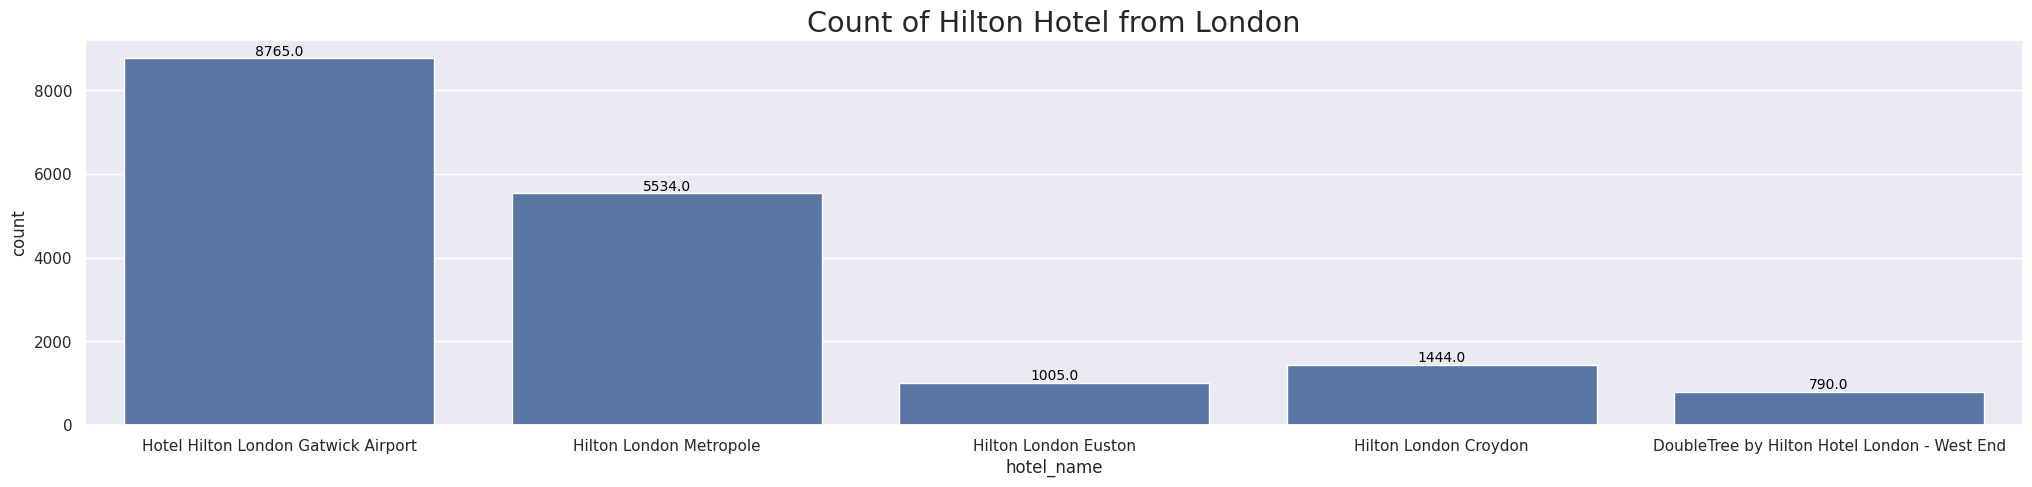

In [ ]:
# Plotting a countplot to visualize the distribution of hotels

sns.set(style="darkgrid")
fig, axes = plt.subplots(1, 1, figsize=(25, 5))

sns.countplot(x="hotel_name", data=raw_data, ax=axes)
plt.title("Count of Hilton Hotel from London", fontsize='xx-large')

# Add count values as callout cards on top of each bar
for p in axes.patches:
    axes.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

In [ ]:
# Groupying the data by "Score" to get some insights on the count of reviews per rating score

scores = pd.DataFrame(raw_data.groupby("score").size().sort_values(ascending=False)).reset_index()
scores.rename(columns={0:'count'}, inplace=True)
scores

,score,count
0,4,5364
1,3,4149
2,5,3787
3,2,2357
4,1,1881


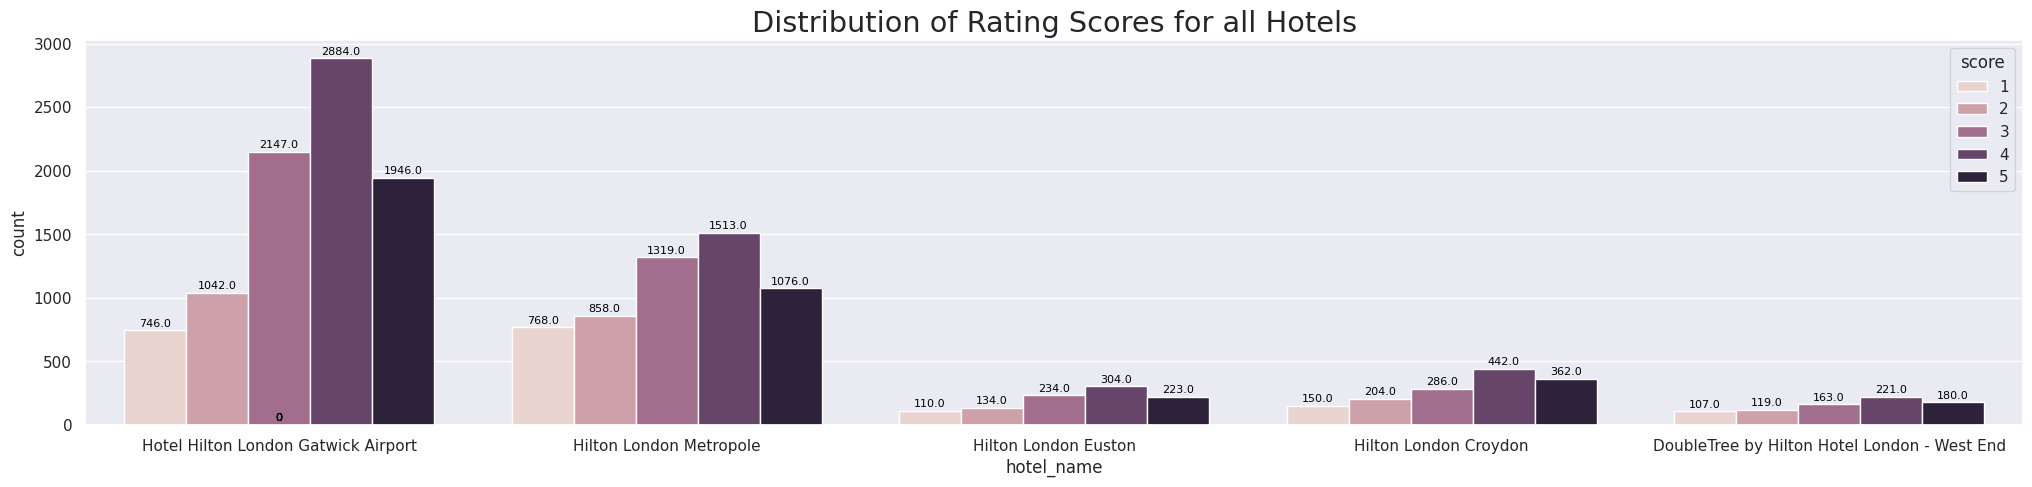

In [ ]:
# Plotting a countplot to visualize the score for each hotel

sns.set(style="darkgrid")
fig, axes = plt.subplots(1, 1, figsize=(25, 5))

sns.countplot(x="hotel_name", hue="score", data=raw_data, ax=axes)
plt.title("Distribution of Rating Scores for all Hotels", fontsize='xx-large')

# Add count values as callout cards on top of each bar
for p in axes.patches:
    axes.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=8, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

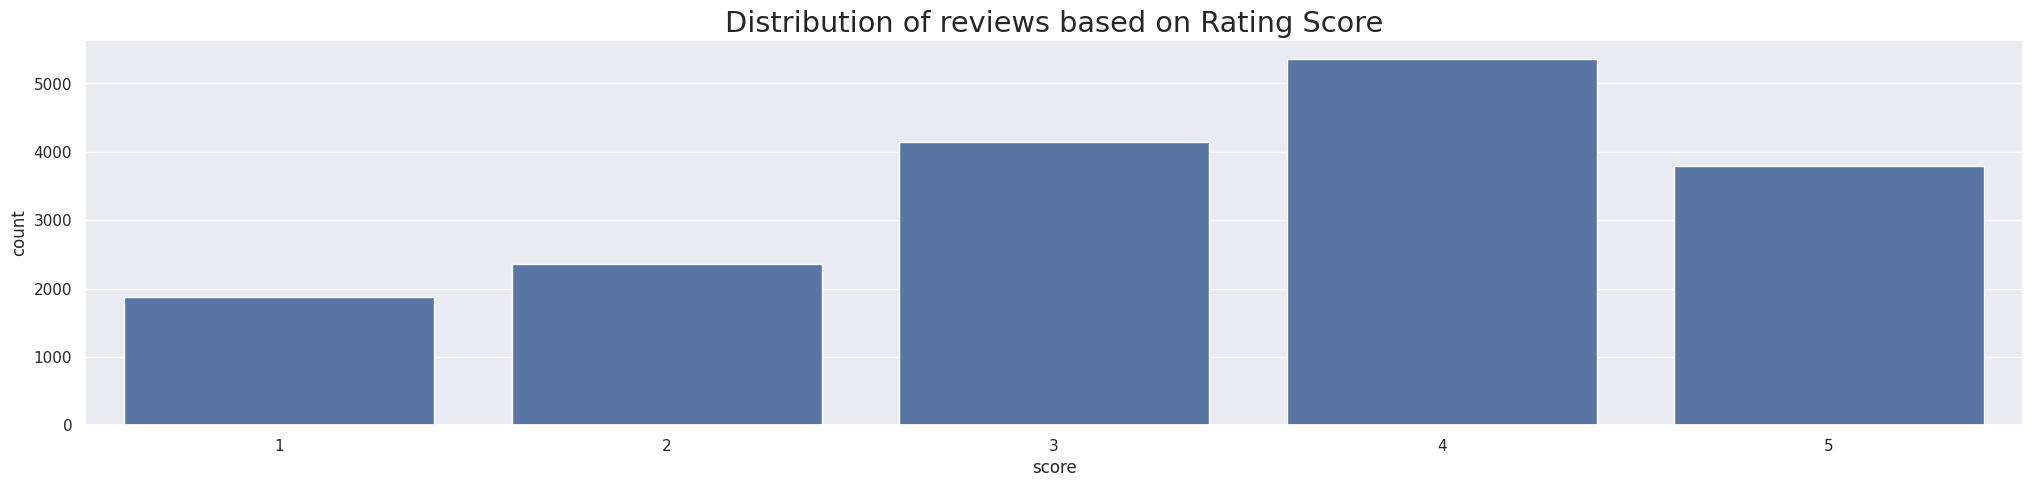

In [ ]:
# Plotting a countplot to visualize the distribution of reviews based on Rating Score

sns.set(style="darkgrid")
fig, axes = plt.subplots(1, 1, figsize=(25, 5))

sns.countplot(x="score", data=raw_data, ax=axes)
plt.title("Distribution of reviews based on Rating Score", fontsize='xx-large')
plt.show()

In [ ]:
# Display 10 most frequent words in the review.
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
word_count = vectorizer.fit_transform(raw_data['review'])
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': word_count.sum(axis=0).A1
})

word_counts_sorted = word_counts.sort_values(by='count', ascending=False)
display(word_counts_sorted.head(10))

,word,count
16073,room,22655
9771,hotel,19617
8857,good,9298
9553,hilton,8160
17766,staff,8146
17870,stay,7472
16079,rooms,6868
17873,stayed,6577
3310,breakfast,6090
12893,night,5391


In [ ]:
# Display 10 random rows from the data.

raw_data.sample(10)

,hotel_name,review_summary,review,score
16622,Hotel Hilton London Gatwick Airport,Excecutive room is worth the money,Arrived at the hotel at 11.30 and was sent to ...,4
4299,Hotel Hilton London Gatwick Airport,Horrible experience,"This hotel is not 4 star , so dissappointed , ...",1
358,Hilton London Metropole,It’s a NO NO...,We stayed at Hilton Metropole for Xmas Holiday...,2
10821,Hotel Hilton London Gatwick Airport,Disappointed,Booked for an overnight stay before flying to ...,1
1800,Hilton London Euston,Great hotel in a great London area.,Close to Regent's park and a good running area...,5
1251,Hotel Hilton London Gatwick Airport,review of Hilton,The front desk is very helpful. The room smell...,3
16797,Hotel Hilton London Gatwick Airport,Thanks to the staff again,I stayed at the Hilton the night before flying...,5
9645,Hotel Hilton London Gatwick Airport,Good for what it is,It's an airport Hilton. What more can be added...,4
1681,DoubleTree by Hilton Hotel London - West End,STAY AWAY!!!!,Honestly I have never stayed a more disappoin...,2
8003,Hotel Hilton London Gatwick Airport,Consistent,Stayed here for a single night as I have done ...,4


# Data Splitting

In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17538 entries, 0 to 17537
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hotel_name      17538 non-null  object
 1   review_summary  17538 non-null  object
 2   review          17538 non-null  object
 3   score           17538 non-null  Int64 
dtypes: Int64(1), object(3)
memory usage: 565.3+ KB


In [ ]:
# Encode labels (e.g. ratings 1–5 → 0–4)
le = LabelEncoder()
raw_data['label_enc'] = le.fit_transform(raw_data['score'])

num_labels = raw_data['label_enc'].nunique()
print("Number of classes:", num_labels)

label_mapping = {int(cls): int(enc) for cls, enc in zip(le.classes_, le.transform(le.classes_))}
print("Label mapping:", label_mapping)

Number of classes: 5
Label mapping: {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}


In [ ]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17538 entries, 0 to 17537
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   hotel_name      17538 non-null  object
 1   review_summary  17538 non-null  object
 2   review          17538 non-null  object
 3   score           17538 non-null  Int64 
 4   label_enc       17538 non-null  int64 
dtypes: Int64(1), int64(1), object(3)
memory usage: 702.3+ KB


In [ ]:
# Saving the Data
path = "/content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data"
os.makedirs(path, exist_ok=True)

raw_data.to_csv(path + "/hotel_reviews_structured.csv", index=False)

In [ ]:
# Define X (features) and y (labels) for splitting

X = raw_data['review'].astype(str).values
y = raw_data['label_enc'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=100, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (14907,)
X_test shape: (2631,)


In [ ]:
print("\nDistribution of labels in y_train:")
print(f"y_train shape: {y_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())
print("\n")
print("\nDistribution of labels in y_test:")
print(f"y_test shape: {y_test.shape}")
print(pd.Series(y_test).value_counts().sort_index())


Distribution of labels in y_train:
y_train shape: (14907,)
0    1599
1    2003
2    3527
3    4559
4    3219
Name: count, dtype: int64



Distribution of labels in y_test:
y_test shape: (2631,)
0    282
1    354
2    622
3    805
4    568
Name: count, dtype: int64


# Data Normalization

In [ ]:
# Text normalization (contractions, emojis, URLs, etc.)
# Class-weight loss was applied inside each models pipeline to address class imbalance.
from utils import normalize_text
X_train = np.array([normalize_text(t) for t in X_train])
X_test = np.array([normalize_text(t) for t in X_test])

print(f"X_train: {X_train.shape}")
print(pd.Series(y_train).value_counts().sort_index())

X_train: (14907,)
0    1599
1    2003
2    3527
3    4559
4    3219
Name: count, dtype: int64


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
ratio_test = X_test.shape[0] / (X_train.shape[0] + X_test.shape[0])
print(f"Ratio of test data: {ratio_test:.2f}")
print("\nDistribution of labels in y_train:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nDistribution of labels in y_test:")
print(pd.Series(y_test).value_counts().sort_index())

X_train shape: (14907,)
y_train shape: (14907,)
X_test shape: (2631,)
y_test shape: (2631,)
Ratio of test data: 0.15

Distribution of labels in y_train:
0    1599
1    2003
2    3527
3    4559
4    3219
Name: count, dtype: int64

Distribution of labels in y_test:
0    282
1    354
2    622
3    805
4    568
Name: count, dtype: int64


# Model Training and Evaluation

## LR Model (Logistic Regression)

In [ ]:
# Pipeline that includes both TfidfVectorizer and LogisticRegression
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(lowercase=True, stop_words='english', ngram_range=(1, 2), max_features=50000)),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, solver='lbfgs', n_jobs=-1)) #using class_weight for class imbalance
])

In [ ]:
# Define the hyperparameter grid
param_grid = {
    'tfidf__max_features': [50000, 100000],  # Number of features (words) to keep
    'lr__C': [0.1, 1, 10],  # Regularization strength
    'lr__penalty': ['l2'],  # L1 for Lasso, L2 for Ridge (L2 works better for Logistic Regression)
}

# Set up cross-validation (StratifiedKFold) and grid search

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',  # Use accuracy for evaluation
    verbose=2,  # Shows progress during search
    n_jobs=-1  # Use all cores
)

In [ ]:
# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and score
print("\nBest Hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)

# Best score (accuracy) achieved during cross-validation
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 6 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best Hyperparameters found by GridSearchCV:
{'lr__C': 1, 'lr__penalty': 'l2', 'tfidf__max_features': 100000}
Best CV Accuracy: 0.5355


In [ ]:
# Best model from grid search
best_model = grid_search.best_estimator_

# Make predictions on the test set
y_test_pred_lr = best_model.predict(X_test)

# Classification report and metrics
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred_lr, target_names=[str(c) for c in le.classes_]))

# Compute and store metrics for Logistic Regression
metrics_lr = compute_metrics(y_test, y_test_pred_lr, model_name="Logistic Regression")


Classification Report (Test Set):
              precision    recall  f1-score   support

         1.0       0.49      0.62      0.55       282
         2.0       0.38      0.39      0.39       354
         3.0       0.52      0.46      0.49       622
         4.0       0.58      0.55      0.57       805
         5.0       0.60      0.63      0.62       568

    accuracy                           0.53      2631
   macro avg       0.52      0.53      0.52      2631
weighted avg       0.54      0.53      0.53      2631


===== Logistic Regression Metrics =====
Accuracy : 0.5336
Precision: 0.5352
Recall   : 0.5336
F1-Score : 0.5329
MAE      : 0.5637


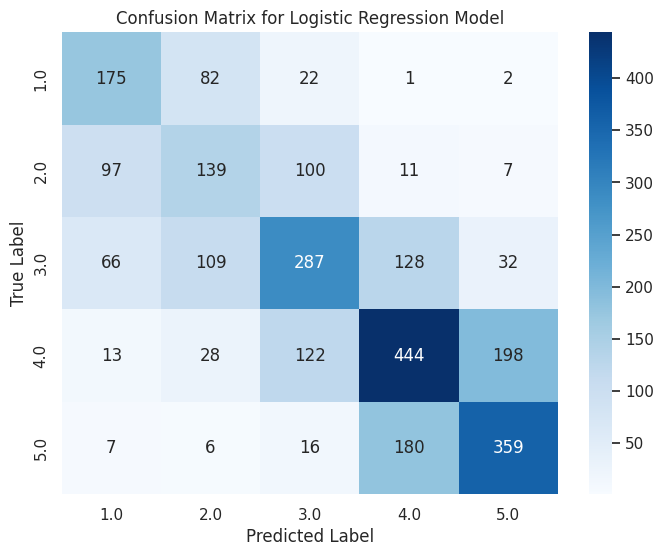

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_test_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in le.classes_], yticklabels=[str(c) for c in le.classes_])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

## LSTM Model (Long Short-Term Memory)

In [ ]:
def create_lstm_model(vocab_size, max_len, embedding_matrix, lstm_units=64, dropout_rate=0.3, learning_rate=1e-3, trainable_embeddings=False):
    embedding_dim = int(embedding_matrix.shape[1])

    model = models.Sequential([
        layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            input_length=max_len,
            weights=[embedding_matrix],
            trainable=trainable_embeddings
        ),
        layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=False)),
        layers.Dropout(dropout_rate),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_labels, activation='softmax')
    ])

    model.build(input_shape=(None, max_len))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# Set a maximum length for the sequences
MAX_LEN = 256

# Initialize and fit tokenizer (needed to map tokens -> ids)
tokenizer = Tokenizer(num_words=None, oov_token="<unk>")
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences  = tokenizer.texts_to_sequences(X_test)

# Pad sequences
X_train_pad = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

VOCAB_SIZE = len(tokenizer.word_index) + 1
print("VOCAB_SIZE:", VOCAB_SIZE)

# Load pre-trained embeddings (GloVe)
GLOVE_PATH = "/content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data/GloVe/glove.6B.100d.txt"
EMBED_DIM  = 100

from utils import load_glove_embeddings, build_embedding_matrix, compute_class_weights

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError(
        f"Missing {GLOVE_PATH}. Download a GloVe .txt file (e.g., glove.6B.100d.txt) and place it next to this notebook."
    )

glove = load_glove_embeddings(GLOVE_PATH, embedding_dim=EMBED_DIM)
embedding_matrix = build_embedding_matrix(tokenizer.word_index, glove, embedding_dim=EMBED_DIM)

# Compute class weights for the training data
class_weights_dict = {i: w for i, w in enumerate(compute_class_weights(y_train, num_classes=num_labels).numpy())}

# Hyperparameter grid (embedding_dim removed because pretrained vectors fix it)
param_grid = {
    'model__lstm_units': [64, 128],
    'model__dropout_rate': [0.2, 0.3],
    'model__learning_rate': [1e-3, 2e-4],
    'epochs': [3, 4],
    'batch_size': [16]
}

# Wrap model for GridSearchCV (SciKeras)
lstm_model = KerasClassifier(
    model=create_lstm_model,
    model__vocab_size=VOCAB_SIZE,
    model__max_len=MAX_LEN,
    model__embedding_matrix=embedding_matrix,
    # Pass class weights directly to KerasClassifier
    class_weight=class_weights_dict,
    verbose=0
)

# StratifiedKFold keeps class distribution across folds
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=55)

grid_search = GridSearchCV(
    estimator=lstm_model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

VOCAB_SIZE: 19805
Loaded pretrained vectors for 16,805 / 19,804 tokens (84.9%).


In [ ]:
# Run grid search for cross-validation + hyperparameter tuning
grid_search.fit(X_train_pad, y_train)

# Best hyperparameters found by GridSearchCV
print("Best Hyperparameters found by GridSearchCV:")
print(grid_search.best_params_)

# Best score (F1 or accuracy) achieved during CV
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Best Hyperparameters found by GridSearchCV:
{'batch_size': 16, 'epochs': 4, 'model__dropout_rate': 0.3, 'model__learning_rate': 0.001, 'model__lstm_units': 128}
Best CV Accuracy: 0.5002


In [ ]:
# Retrain the model with the best hyperparameters
best_params = grid_search.best_params_

# Re-compute class weights for the full training set (X_train, y_train)
# Using num_labels for clarity, ensure it matches the actual number of classes.
class_weights_final_dict = {i: w for i, w in enumerate(compute_class_weights(y_train, num_classes=num_labels).numpy())}

final_model_lstm = create_lstm_model(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    embedding_matrix=embedding_matrix,
    lstm_units=best_params['model__lstm_units'],
    dropout_rate=best_params['model__dropout_rate'],
    learning_rate=best_params['model__learning_rate']
)

final_model_lstm.fit(
    X_train_pad, y_train,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    class_weight=class_weights_final_dict, # Pass class weights here
    verbose=1
)

y_test_pred_probs = final_model_lstm.predict(X_test_pad)
y_test_pred_lstm = np.argmax(y_test_pred_probs, axis=1)

print("\nFinal LSTM Classification Report on Test Set:")
print(classification_report(y_test, y_test_pred_lstm, target_names=[str(c) for c in le.classes_]))

# Metrics (includes MAE)
metrics_lstm = compute_metrics(y_test, y_test_pred_lstm, model_name="LSTM (GloVe)")

Epoch 1/4


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


932/932 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.2264 - loss: 1.5941
Epoch 2/4
932/932 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.4147 - loss: 1.2291
Epoch 3/4
932/932 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.4953 - loss: 1.0937
Epoch 4/4
932/932 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.5150 - loss: 1.0523
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Final LSTM Classification Report on Test Set:
              precision    recall  f1-score   support

         1.0       0.55      0.60      0.57       282
         2.0       0.37      0.51      0.43       354
         3.0       0.53      0.35      0.42       622
         4.0       0.54      0.48      0.51       805
         5.0       0.55      0.70      0.62       568

    accuracy                           0.51      2631
   macro avg       0.51      0.53      0.51      2631
weighted avg       0.52      0.51      0.51      2631


===== LSTM (GloVe) Metrics =====
Accuracy : 0.5116
Precision: 0.5184
Recall   : 0.511

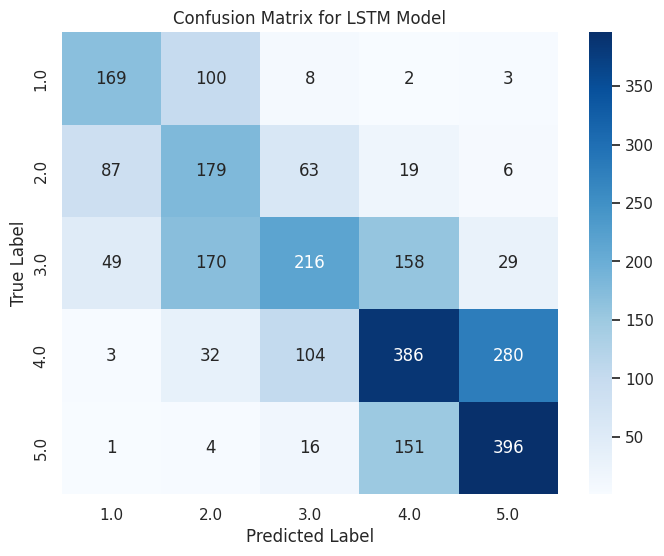

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for LSTM
cm_lstm = confusion_matrix(y_test, y_test_pred_lstm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in le.classes_], yticklabels=[str(c) for c in le.classes_])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for LSTM Model')
plt.show()

## BERT Model (Bidirectional Encoder Representations from Transformers)

In [ ]:
#Tokenizer & Dataset Class

bert_tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

class ReviewDataset(Dataset):
    """
    PyTorch Dataset for hotel review texts and rating labels.

    This dataset takes raw review texts and encoded labels, tokenizes each
    review using a BERT tokenizer, and returns tensors suitable for
    sequence classification.

    Args:
        texts (Sequence[str]): List or array of review texts.
        labels (Sequence[int]): List or array of integer labels (e.g. 0–4).
        tokenizer (transformers.PreTrainedTokenizer): BERT tokenizer to use.
        max_len (int): Maximum sequence length for padding/truncation.

    Returns:
        dict: A dictionary containing:
            - 'input_ids' (torch.LongTensor): Token IDs.
            - 'attention_mask' (torch.LongTensor): Attention mask.
            - 'labels' (torch.LongTensor): Encoded class label.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Tokenize a single review and return input tensors and label.

        Args:
            idx (int): Index of the sample.

        Returns:
            dict: Dictionary with 'input_ids', 'attention_mask', and 'labels'.
        """
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
# Train / Eval Helpers for BERT (with class-weighted loss)
from utils import compute_class_weights, train_one_epoch_weighted, eval_model_weighted


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Small hyperparameter grid (keep this small or you'll fry your GPU)
param_grid = [
    {"lr": 2e-5, "epochs": 4, "max_len": 128},
    {"lr": 2e-5, "epochs": 4, "max_len": 256},
    {"lr": 3e-5, "epochs": 4, "max_len": 128},

]

BATCH_SIZE = 16

cv_results = []

for params in param_grid:
    lr      = params["lr"]
    epochs  = params["epochs"]
    max_len = params["max_len"]

    print(f"\n==============================")
    print(f"Testing hyperparams: lr={lr}, epochs={epochs}, max_len={max_len}")
    print(f"==============================")

    fold_f1s = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        print(f"\n--- Fold {fold} / {skf.n_splits} ---")

        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        # Class weights (handle imbalance without discarding data)
        class_weights = compute_class_weights(y_tr, num_classes=num_labels)


        train_dataset = ReviewDataset(X_tr, y_tr, bert_tokenizer, max_len)
        val_dataset   = ReviewDataset(X_val, y_val, bert_tokenizer, max_len)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

        # New model each fold
        model = BertForSequenceClassification.from_pretrained(
            "bert-base-uncased",
            num_labels=num_labels
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=lr)
        total_steps = len(train_loader) * epochs
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

        best_fold_f1 = 0.0

        for ep in range(epochs):
            print(f"Epoch {ep+1}/{epochs}")
            train_loss = train_one_epoch_weighted(model, train_loader, optimizer, scheduler, device, class_weights)
            val_loss, val_acc, val_prec, val_rec, val_f1, val_mae, _, _ = eval_model_weighted(model, val_loader, device, class_weights)
            print(f"  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_f1={val_f1:.4f}")

            if val_f1 > best_fold_f1:
                best_fold_f1 = val_f1

        fold_f1s.append(best_fold_f1)
        torch.cuda.empty_cache()

    mean_f1 = np.mean(fold_f1s)
    std_f1  = np.std(fold_f1s)
    print(f"\n>>> Hyperparams lr={lr}, epochs={epochs}, max_len={max_len}: "
          f"mean F1={mean_f1:.4f} ± {std_f1:.4f}")

    cv_results.append({
        "lr": lr,
        "epochs": epochs,
        "max_len": max_len,
        "mean_f1": mean_f1,
        "std_f1": std_f1
    })

cv_df = pd.DataFrame(cv_results)
print("\nCV Summary (sorted by mean F1):")
print(cv_df.sort_values("mean_f1", ascending=False))


Testing hyperparams: lr=2e-05, epochs=4, max_len=128

--- Fold 1 / 3 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
  train_loss=1.1664  val_loss=1.0025  val_f1=0.5169
Epoch 2/4
  train_loss=0.8556  val_loss=0.9890  val_f1=0.5761
Epoch 3/4
  train_loss=0.6668  val_loss=1.0490  val_f1=0.5737
Epoch 4/4
  train_loss=0.4944  val_loss=1.1839  val_f1=0.5827

--- Fold 2 / 3 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
  train_loss=1.1761  val_loss=0.9451  val_f1=0.5784
Epoch 2/4
  train_loss=0.8706  val_loss=0.9871  val_f1=0.5848
Epoch 3/4
  train_loss=0.6637  val_loss=1.0304  val_f1=0.5925
Epoch 4/4
  train_loss=0.5023  val_loss=1.1145  val_f1=0.5887

--- Fold 3 / 3 ---


...

Epoch 1/4
  train_loss=1.1505  val_loss=1.0503  val_f1=0.5488
Epoch 2/4
  train_loss=0.8372  val_loss=0.9725  val_f1=0.5857
Epoch 3/4
  train_loss=0.5864  val_loss=1.1499  val_f1=0.5787
Epoch 4/4
  train_loss=0.3796  val_loss=1.3458  val_f1=0.5823

--- Fold 2 / 3 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
  train_loss=1.1669  val_loss=0.9474  val_f1=0.5695
Epoch 2/4
  train_loss=0.8531  val_loss=0.9368  val_f1=0.6082
Epoch 3/4
  train_loss=0.6032  val_loss=1.1136  val_f1=0.5845
Epoch 4/4
  train_loss=0.3934  val_loss=1.2720  val_f1=0.5885

--- Fold 3 / 3 ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
  train_loss=1.1417  val_loss=0.9398  val_f1=0.5753
Epoch 2/4
  train_loss=0.8440  val_loss=0.9721  val_f1=0.5543
Epoch 3/4
  train_loss=0.5984  val_loss=1.1797  val_f1=0.5803
Epoch 4/4
  train_loss=0.3952  val_loss=1.3116  val_f1=0.5778

>>> Hyperparams lr=3e-05, epochs=4, max_len=128: mean F1=0.5914 ± 0.0121

CV Summary (sorted by mean F1):
        lr  epochs  max_len   mean_f1    std_f1
1  0.00002       4      256  0.597336  0.008718
2  0.00003       4      128  0.591398  0.012063
0  0.00002       4      128  0.587730  0.003984


In [ ]:
best_row = cv_df.sort_values("mean_f1", ascending=False).iloc[0]
best_lr      = best_row["lr"]
best_epochs  = int(best_row["epochs"])
best_max_len = int(best_row["max_len"])

print("\nBest hyperparameters from CV:")
print(f"lr={best_lr}, epochs={best_epochs}, max_len={best_max_len}")


Best hyperparameters from CV:
lr=2e-05, epochs=4, max_len=256


In [ ]:
# Final train dataset with best max_len
final_train_dataset = ReviewDataset(X_train, y_train, bert_tokenizer, best_max_len)
final_train_loader  = DataLoader(final_train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Class weights from FULL training set
class_weights = compute_class_weights(y_train, num_classes=num_labels)

# Build test dataset
final_test_dataset = ReviewDataset(X_test, y_test, bert_tokenizer, best_max_len)
final_test_loader  = DataLoader(final_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# New BERT model with best hyperparams
final_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels
).to(device)

optimizer = AdamW(final_model.parameters(), lr=best_lr)
total_steps = len(final_train_loader) * best_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

best_val_f1 = 0.0

for ep in range(best_epochs):
    print(f"\n===== Final Training Epoch {ep+1}/{best_epochs} ====")
    train_loss = train_one_epoch_weighted(final_model, final_train_loader, optimizer, scheduler, device, class_weights)
    print(f"Train loss: {train_loss:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



===== Final Training Epoch 1/4 ====
Train loss: 1.1106

===== Final Training Epoch 2/4 ====
Train loss: 0.8246

===== Final Training Epoch 3/4 ====
Train loss: 0.6394

===== Final Training Epoch 4/4 ====
Train loss: 0.4807


In [ ]:
# Evaluate on Test Set (BERT with class-weighted loss)

test_loss, test_acc, test_prec, test_rec, test_f1, test_mae, y_true_arr, y_pred_arr = eval_model_weighted(
    final_model, final_test_loader, device, class_weights
)

print("\n===== Final BERT on TEST set =====")
print(f"Test loss : {test_loss:.4f}")
print(f"Test acc  : {test_acc:.4f}")
print(f"Test prec : {test_prec:.4f}")
print(f"Test rec  : {test_rec:.4f}")
print(f"Test F1   : {test_f1:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

print("\nClassification Report (BERT):")
print(classification_report(y_true_arr, y_pred_arr, target_names=[str(c) for c in le.classes_]))

metrics_bert = compute_metrics(y_true_arr, y_pred_arr, model_name="BERT (Class-Weighted)")



===== Final BERT on TEST set =====
Test loss : 1.1646
Test acc  : 0.5834
Test prec : 0.5867
Test rec  : 0.5834
Test F1   : 0.5839
Test MAE  : 0.4531

Classification Report (BERT):
              precision    recall  f1-score   support

         1.0       0.60      0.63      0.61       282
         2.0       0.44      0.53      0.48       354
         3.0       0.58      0.51      0.54       622
         4.0       0.61      0.58      0.60       805
         5.0       0.65      0.68      0.66       568

    accuracy                           0.58      2631
   macro avg       0.58      0.59      0.58      2631
weighted avg       0.59      0.58      0.58      2631


===== BERT (Class-Weighted) Metrics =====
Accuracy : 0.5834
Precision: 0.5867
Recall   : 0.5834
F1-Score : 0.5839
MAE      : 0.4531


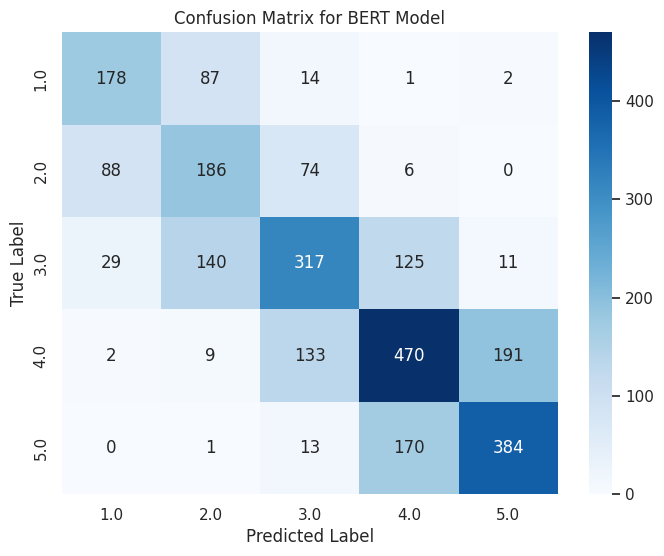

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm_bert = confusion_matrix(y_true_arr, y_pred_arr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in le.classes_], yticklabels=[str(c) for c in le.classes_])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for BERT Model')
plt.show()

# Model Comparison

In [ ]:
# Combine the metrics of all models into one table for comparison
comparison_df = pd.DataFrame([metrics_lr, metrics_lstm, metrics_bert])

print("\nComparison of Models:")
print(comparison_df)


Comparison of Models:
                   model  accuracy  precision    recall        f1       mae
0    Logistic Regression  0.533637   0.535233  0.533637  0.532901  0.563664
1           LSTM (GloVe)  0.511593   0.518432  0.511593  0.506632  0.562524
2  BERT (Class-Weighted)  0.583428   0.586677  0.583428  0.583904  0.453060


# Actionable Insights (Business Drivers from Low-Scoring Reviews)
Using the best-performing model output, we extract recurring n-grams in low-star reviews to highlight operational pain points for management.

In [ ]:
# Imports & Settings

import re
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import BertTokenizer, BertModel
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

LOW_STARS = {1, 2}
N_CLUSTERS = 5
MAX_LEN = 256
BATCH_SIZE = 64

TOP_PHRASES_SHOW = 6
TOP_PHRASES_PRINT = 12
SAMPLES_PER_CLUSTER = 3
RANDOM_STATE = 42

In [ ]:
# Prepare Training Data

X_train_arr = np.array(X_train, dtype=str)
y_train_arr = np.array(y_train)

print("Total reviews:", len(X_train_arr))

Total reviews: 14907


In [ ]:
# Filter Low-Star Reviews

low_mask = np.isin(y_train_arr, list(LOW_STARS))
low_texts = X_train_arr[low_mask]

print(f"Low-star reviews (stars in {LOW_STARS}):", len(low_texts))

if len(low_texts) < N_CLUSTERS:
    raise ValueError("Not enough low-star reviews for clustering.")

Low-star reviews (stars in {1, 2}): 5530


In [ ]:
# Keep Only Negative Low-Star Reviews

NEGATIVE_CUES = [
    "not", "no", "never", "poor", "bad", "dirty", "noise", "noisy",
    "rude", "slow", "delay", "broken", "smell", "issue", "problem",
    "worst", "disappointed", "unacceptable", "refund",
    "terrible", "awful", "refurb", "mould", "mold"
]

def contains_negative(text: str) -> bool:
    return any(cue in text for cue in NEGATIVE_CUES)

neg_mask = np.array([contains_negative(t) for t in low_texts])
neg_texts = low_texts[neg_mask]

print("Negative low-star reviews:", len(neg_texts))

if len(neg_texts) < N_CLUSTERS:
    raise ValueError("Too few negative reviews for clustering.")

Negative low-star reviews: 5181


In [ ]:
# Domain Stopword Removal - Now handled by normalize_text
# Removed redundant DOMAIN_STOPWORDS definition and remove_domain_words function.

neg_texts_filtered = np.array(
    [normalize_text(t) for t in neg_texts], dtype=str
)

In [ ]:
# BERT CLS Embeddings (Best Model)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert = BertModel.from_pretrained("bert-base-uncased").to(device)
bert.eval()


def bert_cls_embeddings(texts):
    embs = []
    with torch.no_grad():
        for i in range(0, len(texts), BATCH_SIZE):
            batch = list(texts[i:i+BATCH_SIZE])
            enc = tokenizer(
                batch,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=MAX_LEN
            ).to(device)
            out = bert(**enc)
            cls = out.last_hidden_state[:, 0, :]
            embs.append(cls.cpu().numpy())
    return np.vstack(embs)

embeddings = bert_cls_embeddings(neg_texts_filtered)
print("Embedding shape:", embeddings.shape)

Using device: cuda
Embedding shape: (5181, 768)


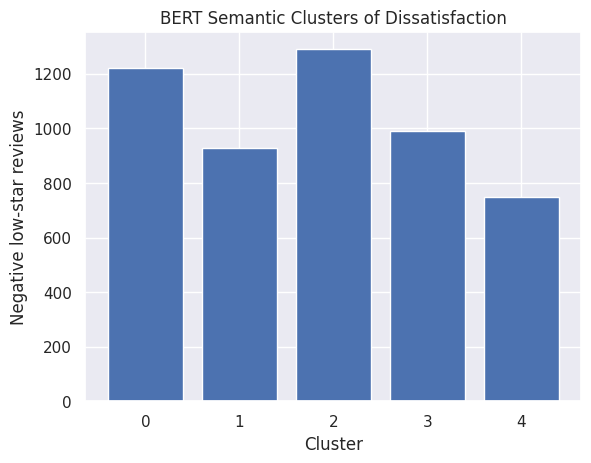

In [ ]:
# KMeans Clustering

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init="auto"
)
clusters = kmeans.fit_predict(embeddings)
sizes = np.bincount(clusters)

plt.figure()
plt.bar(range(N_CLUSTERS), sizes)
plt.xlabel("Cluster")
plt.ylabel("Negative low-star reviews")
plt.title("BERT Semantic Clusters of Dissatisfaction")
plt.show()

In [ ]:
# TF-IDF (Bigrams + Trigrams)

vectorizer = TfidfVectorizer(
    ngram_range=(2, 3),
    stop_words="english",
    min_df=5,
    max_df=0.80,
    sublinear_tf=True
)

tfidf = vectorizer.fit_transform(neg_texts_filtered)
terms = np.array(vectorizer.get_feature_names_out())

In [ ]:
# Extract Negative Drivers per Cluster

NEGATIVE_TERMS_FOR_PHRASES = [
    "not", "no", "dirty", "noisy", "broken", "slow",
    "delay", "smell", "problem", "refurb", "mould",
    "no hot", "cold", "leak"
]

def top_phrases_for_cluster(cluster_id, top_k=12):
    idx = np.where(clusters == cluster_id)[0]
    if len(idx) == 0:
        return []

    mean_scores = np.asarray(tfidf[idx].mean(axis=0)).ravel()
    order = mean_scores.argsort()[::-1]

    phrases = [
        (terms[i], mean_scores[i])
        for i in order
        if any(n in terms[i] for n in NEGATIVE_TERMS_FOR_PHRASES)
    ]
    return phrases[:top_k]

In [ ]:
# Print Results + Sample Reviews

for c in range(N_CLUSTERS):
    print("\n" + "="*60)
    print(f"CLUSTER {c} | size={sizes[c]}")

    print("\nTop negative drivers:")
    drivers = top_phrases_for_cluster(c, TOP_PHRASES_PRINT)
    for p, s in drivers:
        print(f"  {p:<45} {s:.4f}")

    print("\nSample reviews:")
    idxs = np.where(clusters == c)[0][:SAMPLES_PER_CLUSTER]
    for i, si in enumerate(idxs, 1):
        print(f"\nSample {i}: {neg_texts[si][:300]}...")



CLUSTER 0 | size=1222

Top negative drivers:
  hilton honors                                 0.0067
  hilton honours                                0.0064
  north terminal                                0.0050
  honors member                                 0.0028
  honours member                                0.0026
  hilton honors member                          0.0025
  check slow                                    0.0023
  hilton honours member                         0.0021
  refurbished room                              0.0019
  newly refurbished                             0.0018
  non smoking                                   0.0018
  need refurbishment                            0.0017

Sample reviews:

Sample 1: room ok executive room ok although service a little slow and minako restaurant poor with menu not matching that adverstised the price paid for the hotel was ok for london and the location is pretty good too this is a very large hotel and whilst we did not have break

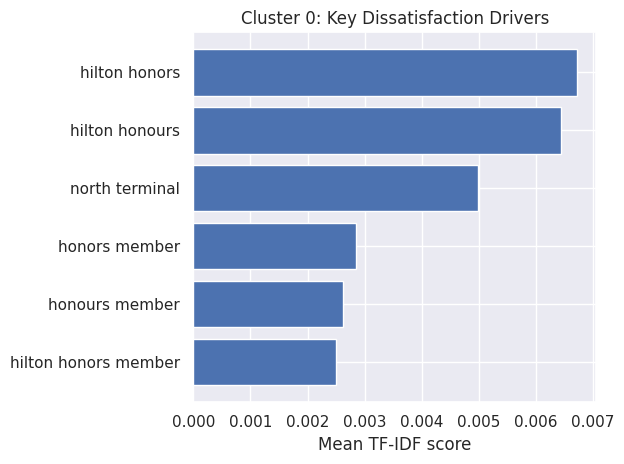

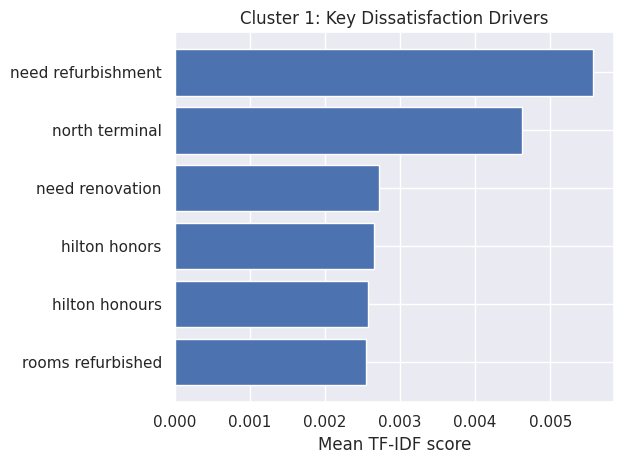

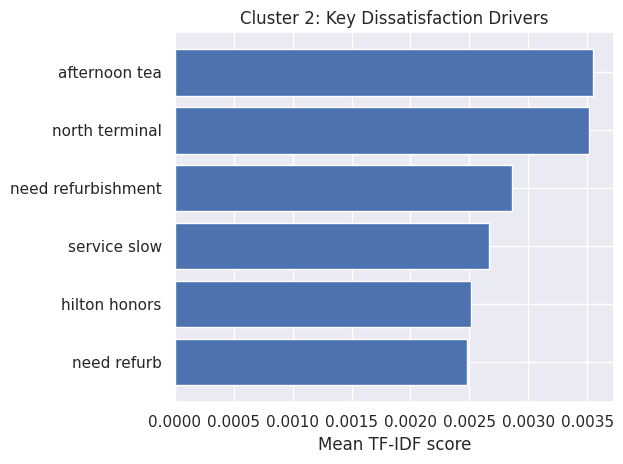

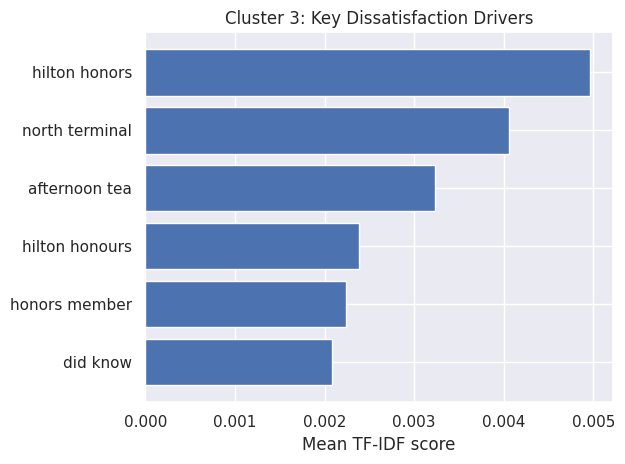

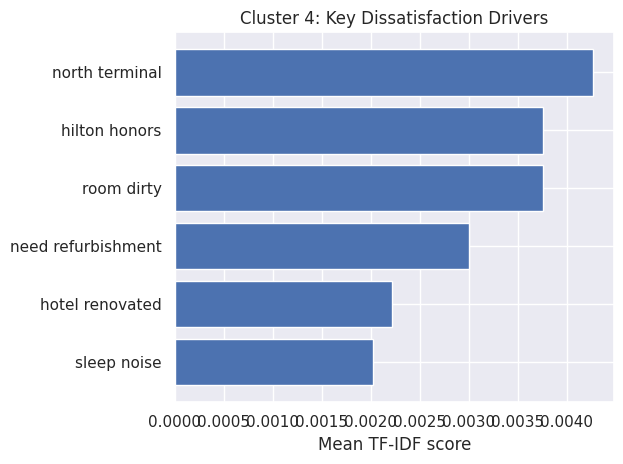

In [ ]:
for c in range(N_CLUSTERS):
    drivers = top_phrases_for_cluster(c, TOP_PHRASES_SHOW)
    if not drivers:
        continue

    phrases = [p for p, _ in drivers][::-1]
    scores = [s for _, s in drivers][::-1]

    plt.figure()
    plt.barh(phrases, scores)
    plt.xlabel("Mean TF-IDF score")
    plt.title(f"Cluster {c}: Key Dissatisfaction Drivers")
    plt.tight_layout()
    plt.show()

In [ ]:
# Management Table

rows = []
total = sizes.sum()

for c in range(N_CLUSTERS):
    top3 = [p for p, _ in top_phrases_for_cluster(c, top_k=3)]
    rows.append({
        "Cluster": c,
        "Count": int(sizes[c]),
        "Share": f"{(sizes[c]/total):.1%}",
        "Top 3 drivers": "; ".join(top3)
    })

drivers_df = pd.DataFrame(rows).sort_values("Count", ascending=False)
display(drivers_df)


,Cluster,Count,Share,Top 3 drivers
2,2,1290,24.9%,afternoon tea; north terminal; need refurbishment
0,0,1222,23.6%,hilton honors; hilton honours; north terminal
3,3,992,19.1%,hilton honors; north terminal; afternoon tea
1,1,927,17.9%,need refurbishment; north terminal; need renov...
4,4,750,14.5%,north terminal; hilton honors; room dirty


# Saving the Best Models

In [ ]:
# Define the directory to save models
models_path = "/content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data/saved_models"
os.makedirs(models_path, exist_ok=True)

# Save BERT Model and Tokenizer
bert_model_save_path = os.path.join(models_path, "bert_sentiment_model")
final_model.save_pretrained(bert_model_save_path)
bert_tokenizer.save_pretrained(bert_model_save_path)
print(f"BERT model and tokenizer saved to: {bert_model_save_path}")

# Save LSTM Model
lstm_model_save_path = os.path.join(models_path, "lstm_sentiment_model.keras")
final_model_lstm.save(lstm_model_save_path)
print(f"LSTM model saved to: {lstm_model_save_path}")

# Save Logistic Regression Model
import joblib
lr_model_save_path = os.path.join(models_path, "lr_sentiment_model.joblib")
joblib.dump(best_model, lr_model_save_path)
print(f"Logistic Regression model saved to: {lr_model_save_path}")

BERT model and tokenizer saved to: /content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data/saved_models/bert_sentiment_model
LSTM model saved to: /content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data/saved_models/lstm_sentiment_model.keras
Logistic Regression model saved to: /content/drive/MyDrive/Colab Datasets/The Hilton Hotel London Data/saved_models/lr_sentiment_model.joblib
